# Erasmus Mobility Flows — Clustering Analysis

**Objective.** Merge the Erasmus mobility dataset with the European university
rankings dataset on institution name, engineer a set of numeric and
categorical features describing each mobility flow, and use unsupervised
learning (K-Means) to check whether mobility records group into distinguishable
clusters. The number of clusters is selected using the elbow method
(inertia) and the silhouette score.

**Scope note.** `df_mobility_hicp.csv` is a 1,000-row sample of the full
Erasmus mobility dataset. All statistics, cluster sizes and proportions
computed below refer only to this sample and to the subset of institutions
that could be matched to the rankings file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, unicodedata

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

## 1. Load raw data

In [2]:
rank = pd.read_csv("european_rankings.csv")
mob = pd.read_csv("df_mobility_hicp.csv").drop(columns=["Unnamed: 0"])

## 2. Data cleaning

The `Sending Country` / `Receiving Country` columns contain inconsistent
spellings for the same country (e.g. `Czech Republic` vs `Czechia`,
`Turkey` vs `Türkiye`). These are harmonized before any further processing.
The `Fewer Opportunities` column also mixes several encodings
(`Yes`/`No`/`1`/`0`/`-`/`???`) and is normalized to `Yes` / `No` / `Unknown`.

In [3]:
country_clean = {
    "Czech Republic": "Czechia",
    "Turkey": "Türkiye",
    "The Republic of North Macedonia": "North Macedonia",
}
mob["Sending Country"] = mob["Sending Country"].replace(country_clean)
mob["Receiving Country"] = mob["Receiving Country"].replace(country_clean)

def clean_fewer_opportunities(v):
    v = str(v).strip().lower()
    return {"yes": "Yes", "1": "Yes", "no": "No", "0": "No"}.get(v, "Unknown")

mob["Fewer_Opportunities_clean"] = mob["Fewer Opportunities"].apply(clean_fewer_opportunities)

## 3. Merge with the rankings dataset

Institution names are not spelled identically across the two files, so an
exact-string merge would miss most rows. Names are normalized (lowercase,
accents stripped, punctuation removed) before matching. Matching is attempted
against **both** the `Sending Organization` and `Receiving Organization`
fields, using the `Academic Year` to pick the rank for the correct year when
available, falling back to the institution's best recorded rank otherwise.

In [4]:
def normalize_name(s):
    s = str(s).lower().strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

rank["norm_inst"] = rank["Institution"].apply(normalize_name)
mob["norm_send"] = mob["Sending Organization"].apply(normalize_name)
mob["norm_recv"] = mob["Receiving Organization"].apply(normalize_name)

rank_lookup = rank.set_index(["norm_inst", "Year"])["European Rank"].to_dict()
rank_best = rank.groupby("norm_inst")["European Rank"].min().to_dict()

def get_rank(name, year):
    r = rank_lookup.get((name, year))
    return r if r is not None else rank_best.get(name, np.nan)

mob["Sending_Rank"] = mob.apply(lambda r: get_rank(r["norm_send"], r["Academic Year"]), axis=1)
mob["Receiving_Rank"] = mob.apply(lambda r: get_rank(r["norm_recv"], r["Academic Year"]), axis=1)

coverage = pd.DataFrame({
    "matched_rows": [mob["Sending_Rank"].notna().sum(), mob["Receiving_Rank"].notna().sum()],
    "total_rows": [len(mob), len(mob)],
}, index=["Sending institution ranked", "Receiving institution ranked"])
coverage["match_rate_%"] = (coverage["matched_rows"] / coverage["total_rows"] * 100).round(1)
coverage

,matched_rows,total_rows,match_rate_%
Sending institution ranked,45,1000,4.5
Receiving institution ranked,56,1000,5.6


The match rate against the rankings file is low (a few percent of rows on
each side), because the mobility sample includes many institutions (business
schools, hospitals, companies, small colleges, host organizations for
traineeships) that do not appear in a *university* ranking list at all. Given
this coverage, `Sending_Rank` / `Receiving_Rank` are kept in the merged
dataset for reference and reporting, but are **not** used as clustering
features — a feature that is missing for >90% of rows would not add reliable
signal to the distance computation. A boolean flag records whether ranking
information is available for each row.

In [5]:
mob["Has_Sending_Rank"] = mob["Sending_Rank"].notna()
mob["Has_Receiving_Rank"] = mob["Receiving_Rank"].notna()
mob[["Sending Organization", "Sending_Rank", "Receiving Organization", "Receiving_Rank"]].dropna(how="all", subset=["Sending_Rank","Receiving_Rank"]).head(10)
#mob[["Sending Organization", "Sending_Rank", "Receiving Organization", "Receiving_Rank"]].dropna(how="any", subset=["Sending_Rank","Receiving_Rank"]).head(10)

,Sending Organization,Sending_Rank,Receiving Organization,Receiving_Rank
31,KATHOLIEKE UNIVERSITEIT LEUVEN,15.0,UNIVERSITAT WIEN,NaN
33,TalTech,NaN,INSA LYON,285.0
62,UNISTRA,NaN,UNIVERSITY OF LIMERICK,344.0
64,TECHNISCHE UNIVERSITAET MUENCHEN,NaN,SCIENCES PO,266.0
72,UNIVERSITY OF GLASGOW,42.0,Agifodent,NaN
73,UNIVERSITY OF BRISTOL,29.0,Sally Perel Gesamtschule,NaN
92,UNIVERSITE PIERRE MENDES FRANCE GRENOBLE-II,NaN,UNIVERSITY OF DUNDEE,94.0
93,UNIVERSITE D'AIX MARSEILLE,NaN,UNIVERSITE LIBRE DE BRUXELLES,86.0
94,UNIVERSITY OF GLASGOW,46.0,UNIVERSIDAD DE SEVILLA,NaN
112,LUISS GUIDO CARLI,NaN,SCIENCES PO,272.0


## 4. Feature engineering

- **`Field_Group`**: the 90 raw `Field of Education` values are mapped onto
  the 10 broad ISCED-F 2013 fields (Business/law, Engineering, Health and
  welfare, etc.) to avoid a very sparse, high-cardinality one-hot encoding.
- **`Sending_Region` / `Receiving_Region`**: countries are grouped into
  Northern / Southern / Western / Eastern Europe or Rest-of-World partner
  countries, to capture broad geographic flow patterns without one-hot
  encoding ~30 individual countries.
- **HICP features**: the raw HICP index has a small number of extreme values
  associated with Türkiye (multi-year currency inflation), which would
  dominate a Euclidean distance. These are winsorized at the 1st/99th
  percentile before computing the sending/receiving/differential features.
- **Country frequency**: how common each country is as a sending/receiving
  country in the sample, as a compact numeric proxy for flow volume.

In [6]:
FIELD_MAP = {
    'Education':'Education','Education science':'Education',
    'Teacher training with subject specialization':'Education',
    'Teacher training without subject specialization':'Education',
    'Training for pre-school teachers':'Education',
    'Arts':'Arts and humanities','Arts and humanities':'Arts and humanities',
    'Audio-visual techniques and media production':'Arts and humanities',
    'Fine arts':'Arts and humanities','History and archaeology':'Arts and humanities',
    'Humanities (except languages)':'Arts and humanities','Language acquisition':'Arts and humanities',
    'Languages':'Arts and humanities','Literature and linguistics':'Arts and humanities',
    'Music and performing arts':'Arts and humanities','Philosophy and ethics':'Arts and humanities',
    'Religion and theology':'Arts and humanities','Fashion, interior and industrial design':'Arts and humanities',
    'Journalism and information':'Social sciences, journalism and information',
    'Journalism and reporting':'Social sciences, journalism and information',
    'Political sciences and civics':'Social sciences, journalism and information',
    'Psychology':'Social sciences, journalism and information',
    'Social and behavioural sciences':'Social sciences, journalism and information',
    'Social sciences, journalism and information':'Social sciences, journalism and information',
    'Sociology and cultural studies':'Social sciences, journalism and information',
    'Accounting and taxation':'Business, administration and law','Business and administration':'Business, administration and law',
    'Business, administration and law':'Business, administration and law','Economics':'Business, administration and law',
    'Finance, banking and insurance':'Business, administration and law','Law':'Business, administration and law',
    'Management and administration':'Business, administration and law','Marketing and advertising':'Business, administration and law',
    'Secretarial and office work':'Business, administration and law','Work skills':'Business, administration and law',
    'Biochemistry':'Natural sciences, mathematics and statistics','Biological and related sciences':'Natural sciences, mathematics and statistics',
    'Biology':'Natural sciences, mathematics and statistics','Chemistry':'Natural sciences, mathematics and statistics',
    'Earth sciences':'Natural sciences, mathematics and statistics','Environment':'Natural sciences, mathematics and statistics',
    'Environmental sciences':'Natural sciences, mathematics and statistics','Mathematics':'Natural sciences, mathematics and statistics',
    'Mathematics and statistics':'Natural sciences, mathematics and statistics','Physical sciences':'Natural sciences, mathematics and statistics',
    'Physics':'Natural sciences, mathematics and statistics','Statistics':'Natural sciences, mathematics and statistics',
    'Computer use':'Information and Communication Technologies (ICTs)',
    'Information and Communication Technologies (ICTs)':'Information and Communication Technologies (ICTs)',
    'Software and applications development and analysis':'Information and Communication Technologies (ICTs)',
    'Architecture and construction':'Engineering, manufacturing and construction',
    'Architecture and town planning':'Engineering, manufacturing and construction',
    'Building and civil engineering':'Engineering, manufacturing and construction',
    'Chemical engineering and processes':'Engineering, manufacturing and construction',
    'Electricity and energy':'Engineering, manufacturing and construction',
    'Electronics and automation':'Engineering, manufacturing and construction',
    'Engineering and engineering trades':'Engineering, manufacturing and construction',
    'Engineering, manufacturing and construction':'Engineering, manufacturing and construction',
    'Environmental protection technology':'Engineering, manufacturing and construction',
    'Food processing':'Engineering, manufacturing and construction',
    'Manufacturing and processing':'Engineering, manufacturing and construction',
    'Mechanics and metal trades':'Engineering, manufacturing and construction',
    'Mining and extraction':'Engineering, manufacturing and construction',
    'Motor vehicles, ships and aircraft':'Engineering, manufacturing and construction',
    'Textiles (clothes, footwear and leather)':'Engineering, manufacturing and construction',
    'Agriculture':'Agriculture, forestry, fisheries and veterinary',
    'Agriculture, forestry, fisheries and veterinary':'Agriculture, forestry, fisheries and veterinary',
    'Crop and livestock production':'Agriculture, forestry, fisheries and veterinary',
    'Forestry':'Agriculture, forestry, fisheries and veterinary','Veterinary':'Agriculture, forestry, fisheries and veterinary',
    'Dental studies':'Health and welfare','Health':'Health and welfare',
    'Medical diagnostic and treatment technology':'Health and welfare','Medicine':'Health and welfare',
    'Nursing and midwifery':'Health and welfare','Pharmacy':'Health and welfare',
    'Therapy and rehabilitation':'Health and welfare','Welfare':'Health and welfare',
    'Social work and counselling':'Health and welfare','Child care and youth services':'Health and welfare',
    'Domestic services':'Services','Hotel, restaurants and catering':'Services',
    'Military and defence':'Services','Personal services':'Services','Security services':'Services',
    'Services':'Services','Sports':'Services','Transport services':'Services',
    'Travel, tourism and leisure':'Services','Wholesale and retail sales':'Services',
}
mob["Field_Group"] = mob["Field of Education"].map(FIELD_MAP)
print("Unmapped values:", mob["Field_Group"].isna().sum())
mob["Field_Group"].value_counts()

Unmapped values: 0


Field_Group
Business, administration and law                     270
Arts and humanities                                  190
Engineering, manufacturing and construction          154
Social sciences, journalism and information          108
Natural sciences, mathematics and statistics          79
Health and welfare                                    73
Services                                              42
Education                                             36
Information and Communication Technologies (ICTs)     29
Agriculture, forestry, fisheries and veterinary       19
Name: count, dtype: int64

In [7]:
REGION = {
 'Denmark':'Northern Europe','Estonia':'Northern Europe','Finland':'Northern Europe','Iceland':'Northern Europe',
 'Ireland':'Northern Europe','Latvia':'Northern Europe','Lithuania':'Northern Europe','Norway':'Northern Europe',
 'Sweden':'Northern Europe','United Kingdom':'Northern Europe',
 'Croatia':'Southern Europe','Cyprus':'Southern Europe','Greece':'Southern Europe','Italy':'Southern Europe',
 'Malta':'Southern Europe','Portugal':'Southern Europe','Slovenia':'Southern Europe','Spain':'Southern Europe',
 'Türkiye':'Southern Europe','Serbia':'Southern Europe','North Macedonia':'Southern Europe',
 'Austria':'Western Europe','Belgium':'Western Europe','France':'Western Europe','Germany':'Western Europe',
 'Luxembourg':'Western Europe','Netherlands':'Western Europe','Switzerland':'Western Europe',
 'Bulgaria':'Eastern Europe','Czechia':'Eastern Europe','Hungary':'Eastern Europe','Poland':'Eastern Europe',
 'Romania':'Eastern Europe','Slovakia':'Eastern Europe','Ukraine':'Eastern Europe','Azerbaijan':'Eastern Europe',
 'Algeria':'Rest of World','Argentina':'Rest of World','Japan':'Rest of World','Lebanon':'Rest of World',
 'Mexico':'Rest of World','Morocco':'Rest of World','Nepal':'Rest of World','Palestine':'Rest of World',
 'South Korea':'Rest of World','United States of America':'Rest of World'
}
mob["Sending_Region"] = mob["Sending Country"].map(REGION)
mob["Receiving_Region"] = mob["Receiving Country"].map(REGION)
#print("Unmapped sending:", mob["Sending_Region"].isna().sum(), "| Unmapped receiving:", mob["Receiving_Region"].isna().sum())

In [8]:
for col in ["Sending Country HICP", "Receiving Country HICP"]:
    lo, hi = mob[col].quantile([0.01, 0.99])
    mob[col + "_w"] = mob[col].clip(lo, hi)

mob["HICP_diff_w"] = mob["Receiving Country HICP_w"] - mob["Sending Country HICP_w"]

mob["Sending_Country_Freq"] = mob["Sending Country"].map(mob["Sending Country"].value_counts(normalize=True))
mob["Receiving_Country_Freq"] = mob["Receiving Country"].map(mob["Receiving Country"].value_counts(normalize=True))

mob[["Sending Country HICP", "Sending Country HICP_w", "Receiving Country HICP",
     "Receiving Country HICP_w", "HICP_diff_w"]].describe()

,Sending Country HICP,Sending Country HICP_w,Receiving Country HICP,Receiving Country HICP_w,HICP_diff_w
count,979.000000,979.000000,979.000000,979.000000,958.000000
mean,116.580020,113.602125,112.306742,109.704840,-3.782716
std,61.947379,31.118231,43.991963,12.074936,27.078243
min,92.810000,99.289000,92.810000,99.278000,-254.980000
25%,100.700000,100.700000,100.655000,100.655000,-2.015000
50%,105.000000,105.000000,104.550000,104.550000,-0.005000
75%,118.700000,118.700000,115.950000,115.950000,1.115000
max,905.210000,370.820000,905.210000,160.363800,52.500000


## 5. Exploratory data analysis

MOLTO DA TOGLIERE

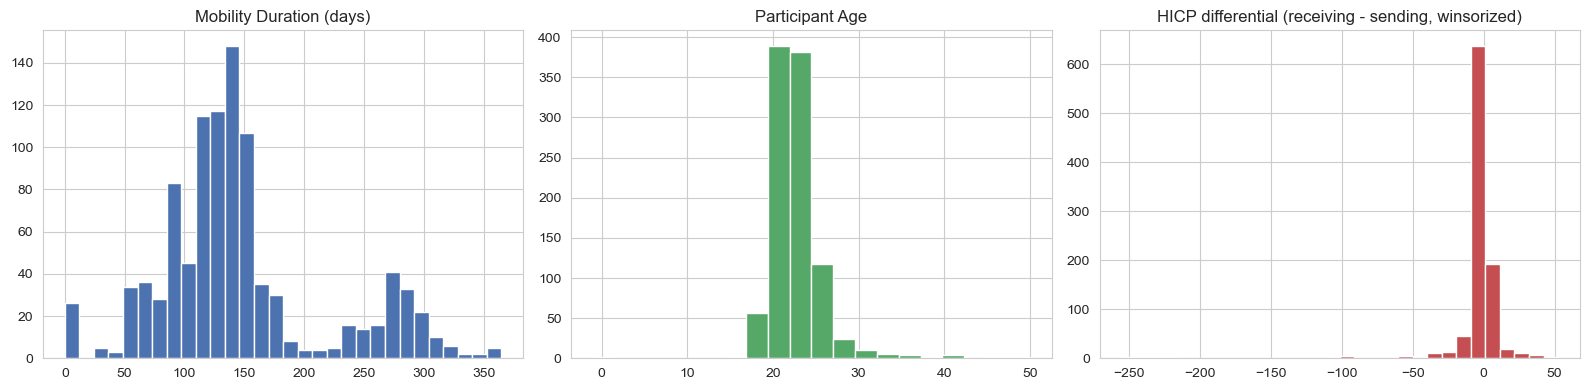

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(mob["Mobility Duration"], bins=30, color="#4C72B0")
axes[0].set_title("Mobility Duration (days)")
axes[1].hist(mob["Participant Age"], bins=20, color="#55A868")
axes[1].set_title("Participant Age")
axes[2].hist(mob["HICP_diff_w"], bins=30, color="#C44E52")
axes[2].set_title("HICP differential (receiving - sending, winsorized)")
plt.tight_layout()
plt.show()

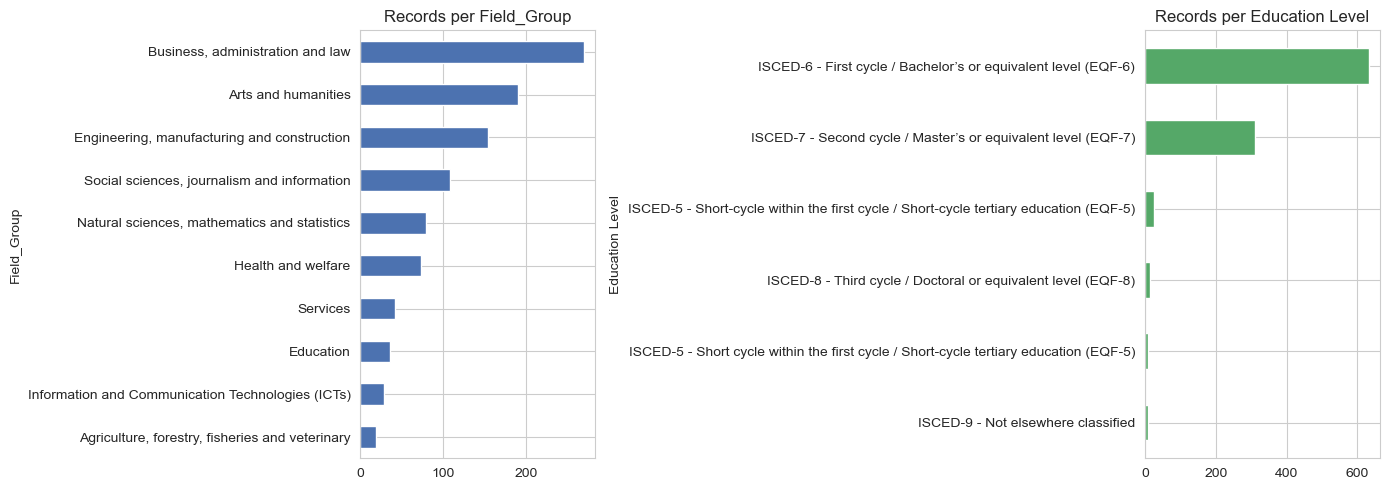

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mob["Field_Group"].value_counts().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Records per Field_Group")
axes[0].invert_yaxis()

mob["Education Level"].value_counts().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Records per Education Level")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

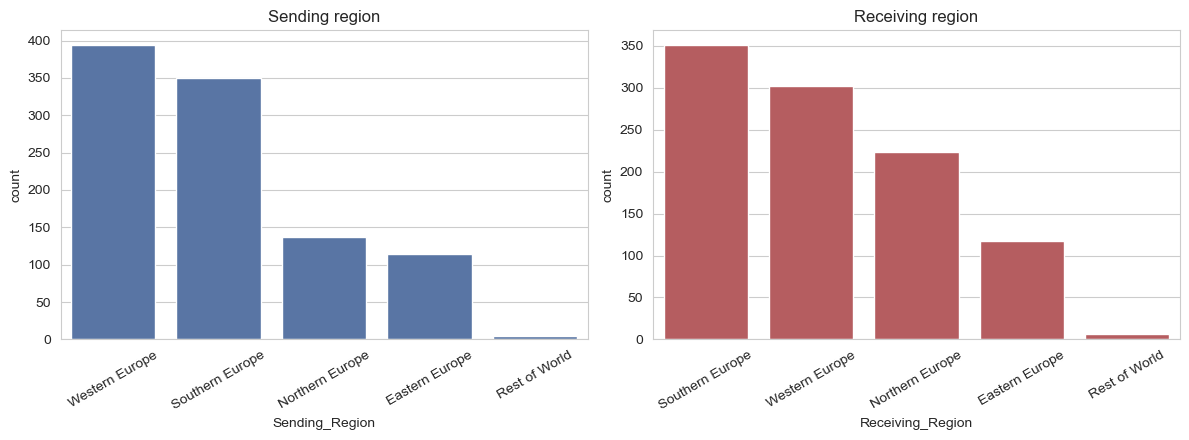

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=mob, x="Sending_Region", order=mob["Sending_Region"].value_counts().index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Sending region")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=mob, x="Receiving_Region", order=mob["Receiving_Region"].value_counts().index, ax=axes[1], color="#C44E52")
axes[1].set_title("Receiving region")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 6. Preprocessing for clustering

In [12]:
num_cols = ["Mobility Duration", "Participant Age", "Sending Country HICP_w",
            "Receiving Country HICP_w", "HICP_diff_w", "Sending_Country_Freq", "Receiving_Country_Freq"]
cat_cols = ["Field_Group", "Education Level", "Participant Gender",
            "Fewer_Opportunities_clean", "Sending_Region", "Receiving_Region"]

X = mob[num_cols + cat_cols].copy()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

X_transformed = preprocessor.fit_transform(X)
print("Feature matrix shape:", X_transformed.shape)

Feature matrix shape: (1000, 38)


## 7. Choosing the number of clusters

Two complementary diagnostics are computed for k = 2..10: the K-Means
inertia (elbow method) and the mean silhouette score.

c:\Users\User\anaconda3\envs\geo\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


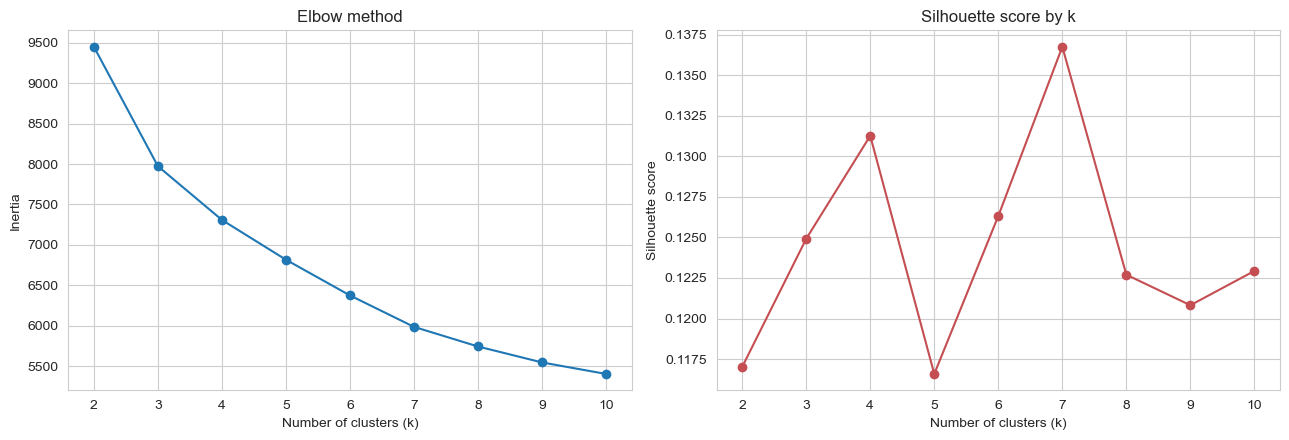

,k,inertia,silhouette
0,2,9450.282792,0.117019
1,3,7972.809610,0.124917
2,4,7308.040201,0.131265
3,5,6815.627064,0.116584
4,6,6374.108306,0.126320
5,7,5985.145099,0.136753
6,8,5742.481879,0.122702
7,9,5545.145281,0.120821
8,10,5402.733622,0.122934


In [13]:
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_transformed)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_transformed, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#C44E52")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score by k")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(k_range), "inertia": inertias, "silhouette": sil_scores})

**Choice of k.** The silhouette score is highest at k=2, but inspecting
that split shows it isolates a handful of rows with extreme values (mobility
flows to/from Türkiye, whose HICP index is far outside the range of the rest
of Europe even after winsorizing) rather than splitting the population into
two broad segments. From k=3 onward the elbow curve flattens and the
silhouette score stabilizes; k=4 is selected as it sits at the bend of the
elbow curve, keeps a local silhouette optimum, and produces cluster sizes
that are all large enough to be interpretable (i.e. no cluster with fewer
than 5 rows other than the genuine small outlier group).

In [14]:
k_final = 4
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
mob["cluster"] = kmeans_final.fit_predict(X_transformed)
mob["cluster"].value_counts().sort_index()

cluster
0    175
1    415
2    400
3     10
Name: count, dtype: int64

## 8. Cluster visualization (PCA projection)

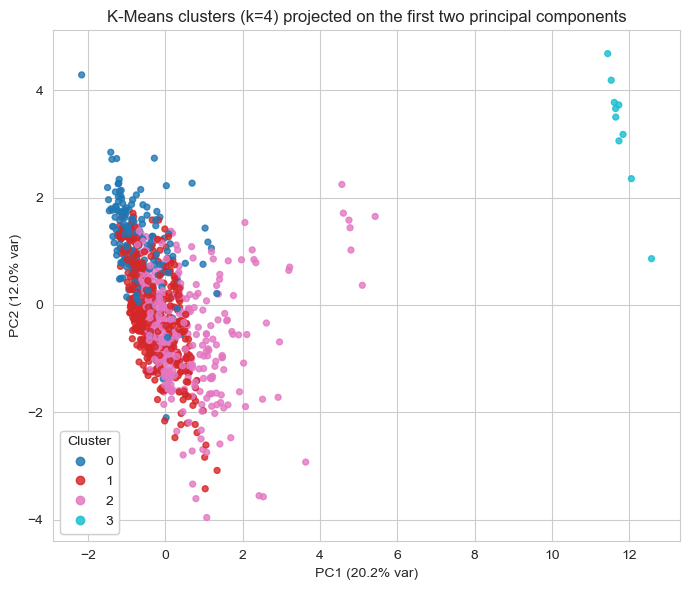

In [15]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_transformed.toarray() if hasattr(X_transformed, "toarray") else X_transformed)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=mob["cluster"], cmap="tab10", s=18, alpha=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("K-Means clusters (k=4) projected on the first two principal components")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

## 9. Cluster profiling

Mean of the numeric features and most frequent categories per cluster.

In [16]:
profile_num = mob.groupby("cluster")[num_cols].mean().round(1)
profile_num["n_rows"] = mob["cluster"].value_counts().sort_index()
profile_num

,Mobility Duration,Participant Age,Sending Country HICP_w,Receiving Country HICP_w,HICP_diff_w,Sending_Country_Freq,Receiving_Country_Freq,n_rows
cluster,,,,,,,,
0,276.7,21.6,107.3,106.7,-0.9,0.1,0.1,175
1,120.7,22.6,108.7,110.0,1.6,0.1,0.1,415
2,117.6,22.9,115.0,110.1,-4.6,0.0,0.1,400
3,102.6,25.1,370.8,134.0,-236.9,0.1,0.1,10


In [17]:
for c in cat_cols:
    print(f"--- {c} ---")
    print(mob.groupby("cluster")[c].agg(lambda s: s.value_counts(normalize=True).round(2).head(3).to_dict()))
    print()

--- Field_Group ---
cluster
0    {'Arts and humanities': 0.27, 'Business, admin...
1    {'Business, administration and law': 0.3, 'Art...
2    {'Business, administration and law': 0.26, 'Ar...
3    {'Engineering, manufacturing and construction'...
Name: Field_Group, dtype: object

--- Education Level ---
cluster
0    {'ISCED-6 - First cycle / Bachelor’s or equiva...
1    {'ISCED-6 - First cycle / Bachelor’s or equiva...
2    {'ISCED-6 - First cycle / Bachelor’s or equiva...
3    {'ISCED-6 - First cycle / Bachelor’s or equiva...
Name: Education Level, dtype: object

--- Participant Gender ---
cluster
0    {'Female': 0.61, 'Male': 0.39}
1      {'Female': 0.6, 'Male': 0.4}
2    {'Female': 0.66, 'Male': 0.34}
3      {'Male': 0.8, 'Female': 0.2}
Name: Participant Gender, dtype: object

--- Fewer_Opportunities_clean ---
cluster
0    {'No': 0.76, 'Yes': 0.16, 'Unknown': 0.08}
1     {'No': 0.83, 'Yes': 0.1, 'Unknown': 0.07}
2    {'No': 0.86, 'Yes': 0.09, 'Unknown': 0.05}
3                     

C:\Users\User\AppData\Local\Temp\ipykernel_356\3124846326.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mob, x="cluster", y="Mobility Duration", ax=axes[0,0], palette="tab10")
C:\Users\User\AppData\Local\Temp\ipykernel_356\3124846326.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mob, x="cluster", y="Participant Age", ax=axes[0,1], palette="tab10")
C:\Users\User\AppData\Local\Temp\ipykernel_356\3124846326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mob, x="cluster", y="HICP_diff_w", ax=axes[1,0], palette="ta

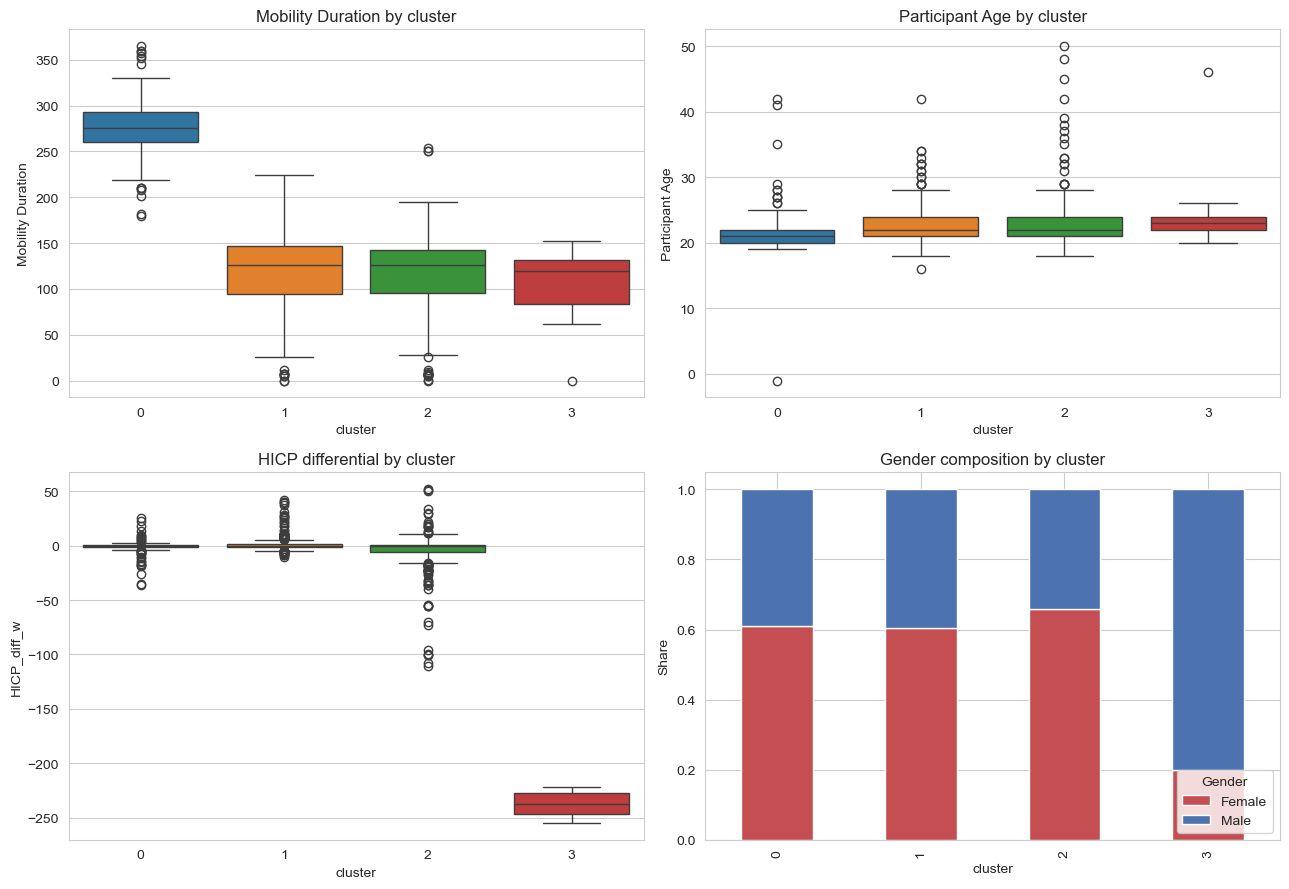

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(data=mob, x="cluster", y="Mobility Duration", ax=axes[0,0], palette="tab10")
axes[0,0].set_title("Mobility Duration by cluster")

sns.boxplot(data=mob, x="cluster", y="Participant Age", ax=axes[0,1], palette="tab10")
axes[0,1].set_title("Participant Age by cluster")

sns.boxplot(data=mob, x="cluster", y="HICP_diff_w", ax=axes[1,0], palette="tab10")
axes[1,0].set_title("HICP differential by cluster")

gender_ct = pd.crosstab(mob["cluster"], mob["Participant Gender"], normalize="index")
gender_ct.plot(kind="bar", stacked=True, ax=axes[1,1], color=["#C44E52","#4C72B0"])
axes[1,1].set_title("Gender composition by cluster")
axes[1,1].set_ylabel("Share")
axes[1,1].legend(title="Gender", loc="lower right")

plt.tight_layout()
plt.show()

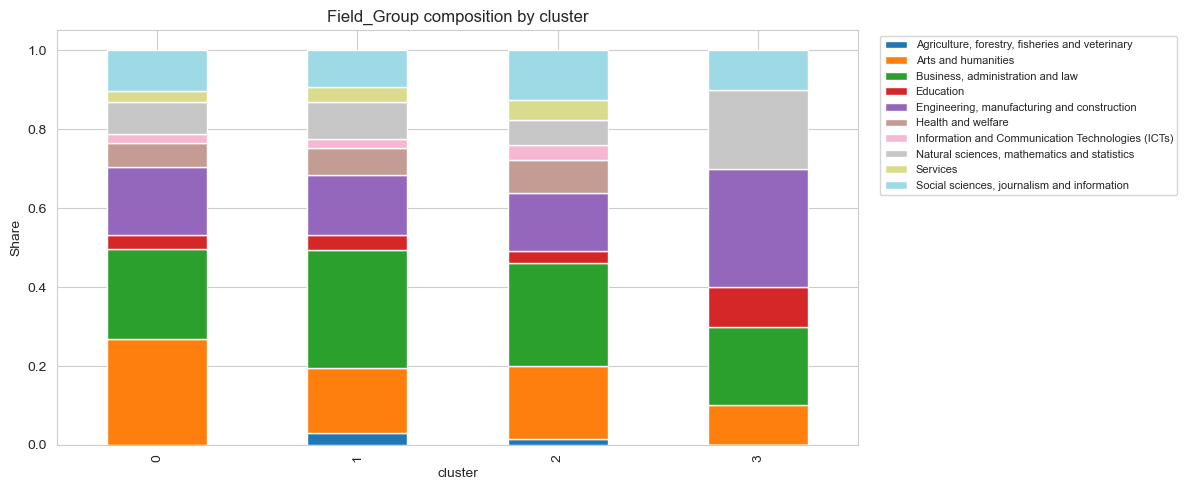

In [19]:
field_ct = pd.crosstab(mob["cluster"], mob["Field_Group"], normalize="index")
fig, ax = plt.subplots(figsize=(12, 5))
field_ct.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Field_Group composition by cluster")
ax.set_ylabel("Share")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

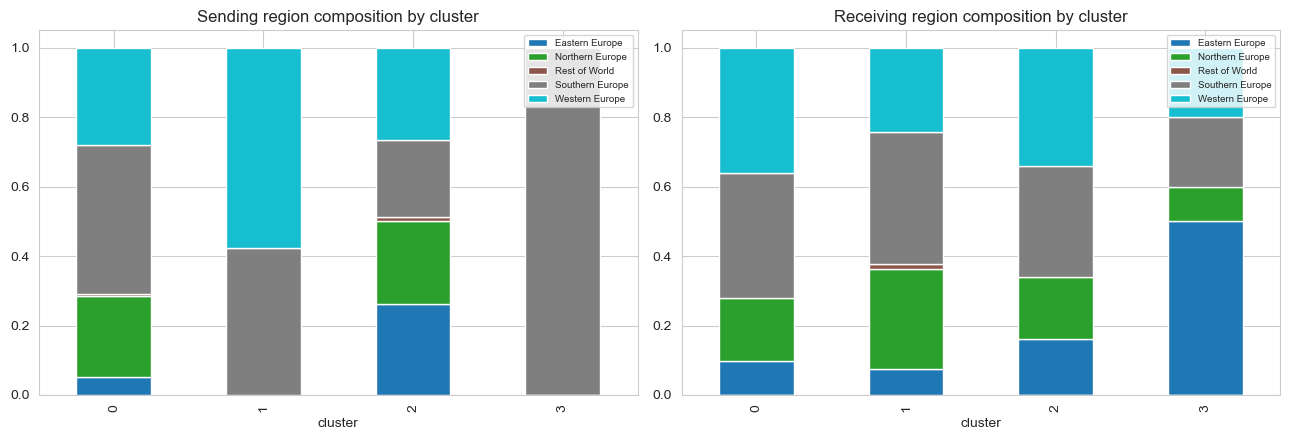

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
send_ct = pd.crosstab(mob["cluster"], mob["Sending_Region"], normalize="index")
send_ct.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10")
axes[0].set_title("Sending region composition by cluster")
axes[0].legend(fontsize=7)

recv_ct = pd.crosstab(mob["cluster"], mob["Receiving_Region"], normalize="index")
recv_ct.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab10")
axes[1].set_title("Receiving region composition by cluster")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 10. Silhouette diagnostic for the chosen k

Per-sample silhouette values for k=4, to check that no cluster is
systematically poorly separated.

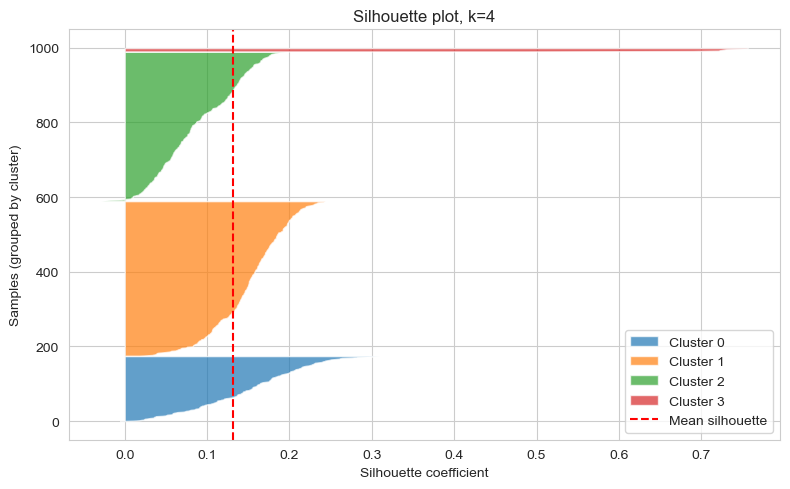

In [21]:
sil_vals = silhouette_samples(X_transformed, mob["cluster"])
fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 0
for i in sorted(mob["cluster"].unique()):
    vals = np.sort(sil_vals[mob["cluster"] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, label=f"Cluster {i}")
    y_lower = y_upper
ax.axvline(sil_vals.mean(), color="red", linestyle="--", label="Mean silhouette")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (grouped by cluster)")
ax.set_title("Silhouette plot, k=4")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Export merged dataset with cluster labels

In [22]:
output_cols = ["Academic Year","Mobility Duration","Field of Education","Field_Group","Participant Country",
               "Education Level","Participant Gender","Fewer_Opportunities_clean","Participant Age",
               "Sending Country","Sending_Region","Sending Country HICP","Sending City","Sending Organization",
               "Sending_Rank","Has_Sending_Rank",
               "Receiving Country","Receiving_Region","Receiving Country HICP","Receiving City","Receiving Organization",
               "Receiving_Rank","Has_Receiving_Rank","HICP_diff_w","cluster"]

mob_out = mob[output_cols].rename(columns={"HICP_diff_w":"HICP_diff"})
mob_out.to_csv("erasmus_mobility_merged_clustered.csv", index=False)
mob_out.head()

,Academic Year,Mobility Duration,Field of Education,Field_Group,Participant Country,Education Level,Participant Gender,Fewer_Opportunities_clean,Participant Age,Sending Country,Sending_Region,Sending Country HICP,Sending City,Sending Organization,Sending_Rank,Has_Sending_Rank,Receiving Country,Receiving_Region,Receiving Country HICP,Receiving City,Receiving Organization,Receiving_Rank,Has_Receiving_Rank,HICP_diff,cluster
0,2016,121,Arts,Arts and humanities,France,ISCED-7 - Second cycle / Master’s or equivalen...,Male,Yes,25,France,Western Europe,100.31,METZ,Ecole Supérieure d'Art de Lorraine,NaN,False,Türkiye,Southern Europe,107.66,ISTANBUL,Sabanci University,NaN,False,7.35,1
1,2019,42,Chemistry,"Natural sciences, mathematics and statistics",Belgium,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,No,21,Belgium,Western Europe,107.77,Geel,THOMAS MORE KEMPEN VZW,NaN,False,Poland,Eastern Europe,104.80,Gdansk,UNIWERSYTET GDANSKI,NaN,False,-2.97,2
2,2017,139,Business and administration,"Business, administration and law",France,ISCED-7 - Second cycle / Master’s or equivalen...,Male,No,24,France,Western Europe,101.47,BELFORT,ASSOCIATION POUR LA GESTION DE L'ECOLE SUPERIE...,NaN,False,Germany,Western Europe,102.10,BIETIGHEIM-BISSINGEN,MAGNA CAR TOP SYSTEMS GmbH,NaN,False,0.63,1
3,2017,140,Journalism and reporting,"Social sciences, journalism and information",United Kingdom,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,No,20,United Kingdom,Northern Europe,103.40,SOUTHAMPTON,Southampton Solent University,NaN,False,Spain,Southern Europe,101.69,VILLANUEVA DE GALLEGO ZARAGOZA,FUNDACION UNIVERSIDAD SAN JORGE,NaN,False,-1.71,2
4,2019,134,Economics,"Business, administration and law",Czechia,ISCED-7 - Second cycle / Master’s or equivalen...,Female,No,23,Czechia,Eastern Europe,107.80,OSTRAVA PORUBA,VYSOKA SKOLA BANSKA - TECHNICKA UNIVERZITA OST...,NaN,False,Greece,Southern Europe,102.46,PIRAEUS,UNIVERSITY OF PIRAEUS RESEARCH CENTER,NaN,False,-5.34,2
